Análise Exploratória de Dados (EDA): Pokémon VGC Pro

Este notebook faz parte de um trabalho de Estatística e apresenta a análise do dataset Pokemon Complete Stas Gen1 to Gen9 com o Objetivo de: Investigar padrões estatísticos, equilíbrios de tipos e o fenômeno do Power Creep para fundamentar decisões estratégicas no cenário competitivo.

1. Exploração e Tratamento dos Dados para Análise

1.1 Visualização inicial dos dados

In [28]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [3]:
df = pd.read_csv('pokemon_data.csv')

In [4]:
df.head(5)

,ID,Name,HP,Attack,Defense,Sp. Attack,Sp. Defense,Speed,Base_Stats,normal_weakness,...,Classification_info,Forms,gen,Is_Legendary,Is_Mythical,Is_Ultra_Beast,number_immune,number_not_effective,number_normal,number_super_effective
0,1,Bulbasaur,45,49,49,65,65,45,318,1.0,...,Seed,NaN,1,0,0,0,0,5,9,4
1,2,Ivysaur,60,62,63,80,80,60,405,1.0,...,Seed,NaN,1,0,0,0,0,5,9,4
2,3,Venusaur,80,82,83,100,100,80,525,1.0,...,Seed,Mega Venusaur,1,0,0,0,0,5,9,4
3,4,Charmander,39,52,43,60,50,65,309,1.0,...,Lizard,NaN,1,0,0,0,0,6,9,3
4,5,Charmeleon,58,64,58,80,65,80,405,1.0,...,Flame,NaN,1,0,0,0,0,6,9,3


In [5]:
print("dimensões do dataset (Linha,Coluna):")
print(df.shape)

dimensões do dataset (Linha,Coluna):
(1025, 48)


In [6]:
print("Tipos de dados por coluna")
df.dtypes

Tipos de dados por coluna


ID                          int64
Name                       object
HP                          int64
Attack                      int64
Defense                     int64
Sp. Attack                  int64
Sp. Defense                 int64
Speed                       int64
Base_Stats                  int64
normal_weakness           float64
fire_weakness             float64
water_weakness            float64
electric_weakness         float64
grass_weakness            float64
ice_weakness              float64
fighting_weakness         float64
poison_weakness           float64
ground_weakness           float64
flying_weakness           float64
psychic_weakness          float64
bug_weakness              float64
rock_weakness             float64
ghost_weakness            float64
dragon_weakness           float64
dark_weakness             float64
steel_weakness            float64
fairy_weakness            float64
height_inches               int64
height_meters             float64
weight_pounds 

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 48 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      1025 non-null   int64  
 1   Name                    1025 non-null   object 
 2   HP                      1025 non-null   int64  
 3   Attack                  1025 non-null   int64  
 4   Defense                 1025 non-null   int64  
 5   Sp. Attack              1025 non-null   int64  
 6   Sp. Defense             1025 non-null   int64  
 7   Speed                   1025 non-null   int64  
 8   Base_Stats              1025 non-null   int64  
 9   normal_weakness         1025 non-null   float64
 10  fire_weakness           1025 non-null   float64
 11  water_weakness          1025 non-null   float64
 12  electric_weakness       1025 non-null   float64
 13  grass_weakness          1025 non-null   float64
 14  ice_weakness            1025 non-null   

1.2 Buscando valores ausentes ou duplicados

In [8]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")

Linhas duplicadas: 0


In [9]:
print(f"Valores nulos por coluna:\n{df.isnull().sum()}")

Valores nulos por coluna:
ID                          0
Name                        0
HP                          0
Attack                      0
Defense                     0
Sp. Attack                  0
Sp. Defense                 0
Speed                       0
Base_Stats                  0
normal_weakness             0
fire_weakness               0
water_weakness              0
electric_weakness           0
grass_weakness              0
ice_weakness                0
fighting_weakness           0
poison_weakness             0
ground_weakness             0
flying_weakness             0
psychic_weakness            0
bug_weakness                0
rock_weakness               0
ghost_weakness              0
dragon_weakness             0
dark_weakness               0
steel_weakness              0
fairy_weakness              0
height_inches               0
height_meters               0
weight_pounds               0
weight_kilograms            0
capturing_rate              0
gender_male_ra

1.3 Tratamento de Nulos: Preenchimento da coluna Type 2 com "None" para Pokémon de tipo único, evitando erros em cálculos agregados.

In [23]:
df['Type 2'] = df['Type 2'].fillna('None')
df[['Name', 'Type 1', 'Type 2']].head()

,Name,Type 1,Type 2
0,Bulbasaur,Grass,Poison
1,Ivysaur,Grass,Poison
2,Venusaur,Grass,Poison
3,Charmander,Fire,None
4,Charmeleon,Fire,None


1.4 Feature Engineering: Criação da coluna Base_Stats (BST) somando todos os atributos básicos (HP, Atk, Def, SpA, SpD, Spe).

In [22]:
stats_list = ['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed']
df['Base_Stats'] = df[stats_list].sum(axis=1)
print(f"Colunas de Status tratadas: {stats_list}")
df[['Name','Base_Stats']].head()

Colunas de Status tratadas: ['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed']


,Name,Base_Stats
0,Bulbasaur,318
1,Ivysaur,405
2,Venusaur,525
3,Charmander,309
4,Charmeleon,405


1.5 Categorização: Agrupamento por Gerações e classificação de raridade (Míticos, Lendários, Ultra Beasts) para análises de hierarquia.

In [21]:
def classify_rarity(row):
    """
    Classifica o Pokémon em categorias competitivas de raridade.
    Prioridade: Mítico > Ultra Beast > Lendário > Comum.
    """
    if row.get('Is_Mythical') == 1: 
        return 'Mítico'
    if row.get('Is_Ultra_Beast') == 1: 
        return 'Ultra Beast'
    if row.get('Is_Legendary') == 1: 
        return 'Lendário'
    return 'Comum'

# Aplicando a classificação e transformando em categoria ordenada para facilitar gráficos
df['Rarity'] = df.apply(classify_rarity, axis=1)
rarity_order = ['Comum', 'Ultra Beast', 'Mítico', 'Lendário']
df['Rarity'] = pd.Categorical(df['Rarity'], categories=rarity_order, ordered=True)

df[['Name','Rarity']].head()

,Name,Rarity
0,Bulbasaur,Comum
1,Ivysaur,Comum
2,Venusaur,Comum
3,Charmander,Comum
4,Charmeleon,Comum


In [ ]:
sns.set_theme(style="whitegrid", palette="muted")

df['capturing_rate'] = pd.to_numeric(df['capturing_rate'], errors='coerce')
df['weight_kilograms'] = pd.to_numeric(df['weight_kilograms'], errors='coerce')

2. Análise de Distribuição e Frequência de Tipos

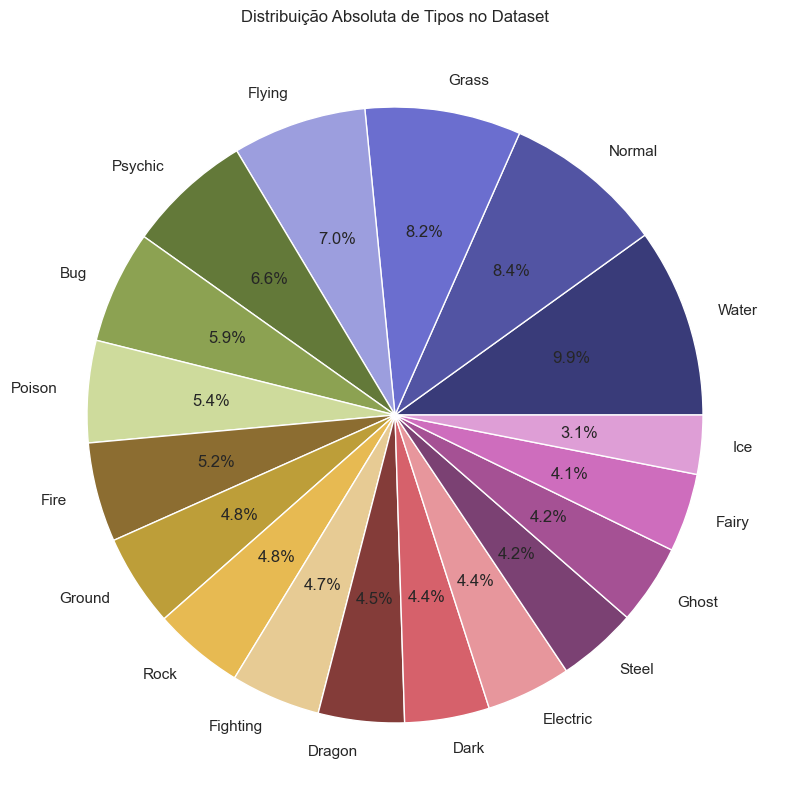

In [19]:
# Analisando a distribuição real de tipos (unificando Type 1 e Type 2)
todos_tipos = pd.concat([df['Type 1'], df['Type 2']])
todos_tipos = todos_tipos[todos_tipos != 'None'] # Remove os vazios

plt.figure(figsize=(10,10))
todos_tipos.value_counts().plot.pie(autopct='%1.1f%%', cmap='tab20b')
plt.title('Distribuição Absoluta de Tipos no Dataset')
plt.ylabel('')
plt.show()

3. Power Creep: A Evolução do Poder através das Gerações

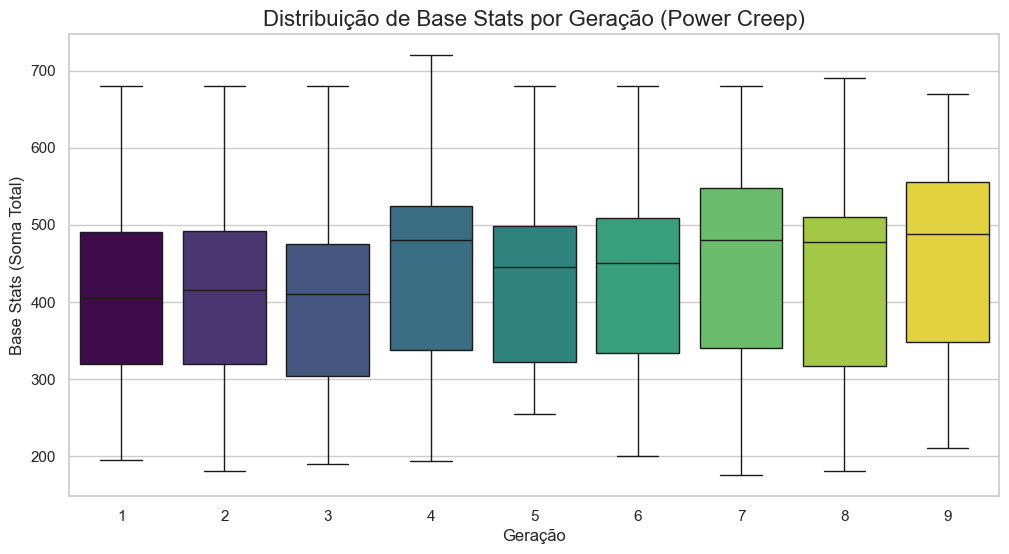

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='gen', y='Base_Stats', data=df, hue='gen', palette='viridis', legend=False)
plt.title('Distribuição de Base Stats por Geração (Power Creep)', fontsize=16)
plt.xlabel('Geração', fontsize=12)
plt.ylabel('Base Stats (Soma Total)', fontsize=12)
plt.show()

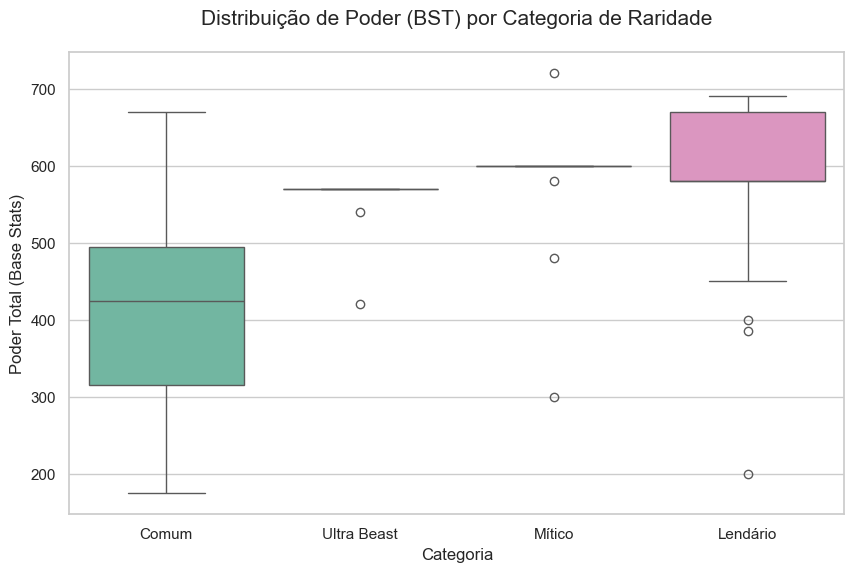

In [24]:
plt.figure(figsize=(10, 6))

# Boxplot para mostrar a distribuição de poder por categoria
sns.boxplot(x='Rarity', y='Base_Stats', data=df, palette="Set2", hue='Rarity', legend=False)

plt.title('Distribuição de Poder (BST) por Categoria de Raridade', fontsize=15, pad=20)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Poder Total (Base Stats)', fontsize=12)
plt.show()

4. Correlação Estratégica: Speed vs Offense

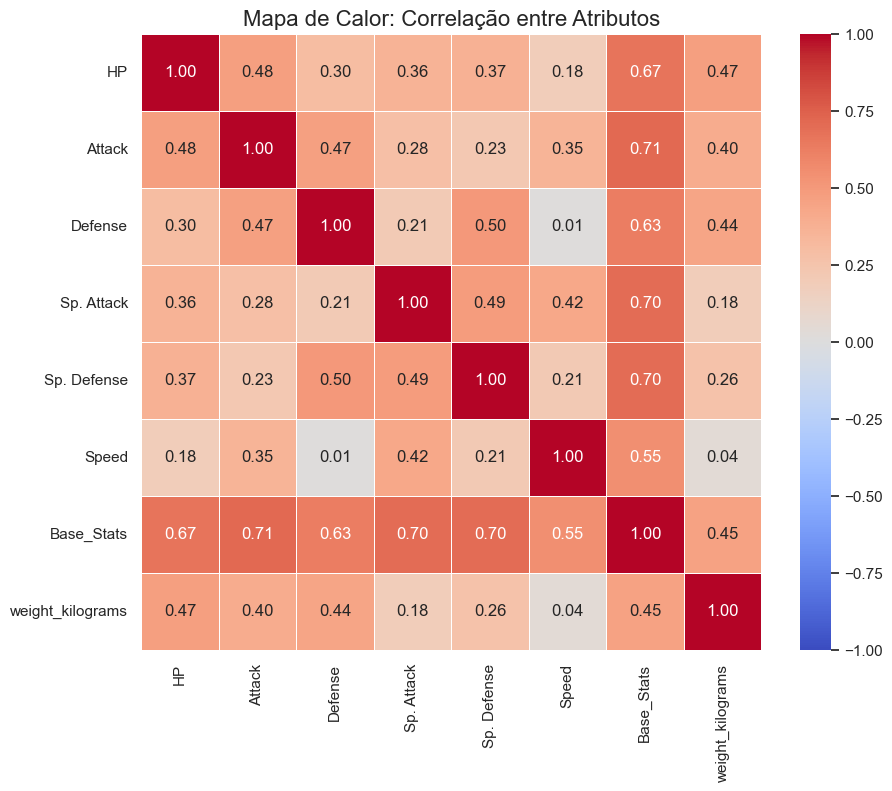

In [13]:
plt.figure(figsize=(10, 8))

# Selecionando apenas as colunas numéricas de atributos físicos e stats
cols_heatmap = ['HP', 'Attack', 'Defense', 'Sp. Attack', 'Sp. Defense', 'Speed', 'Base_Stats', 'weight_kilograms']
corr = df[cols_heatmap].corr()

# Criando o Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Calor: Correlação entre Atributos', fontsize=16)
plt.show()

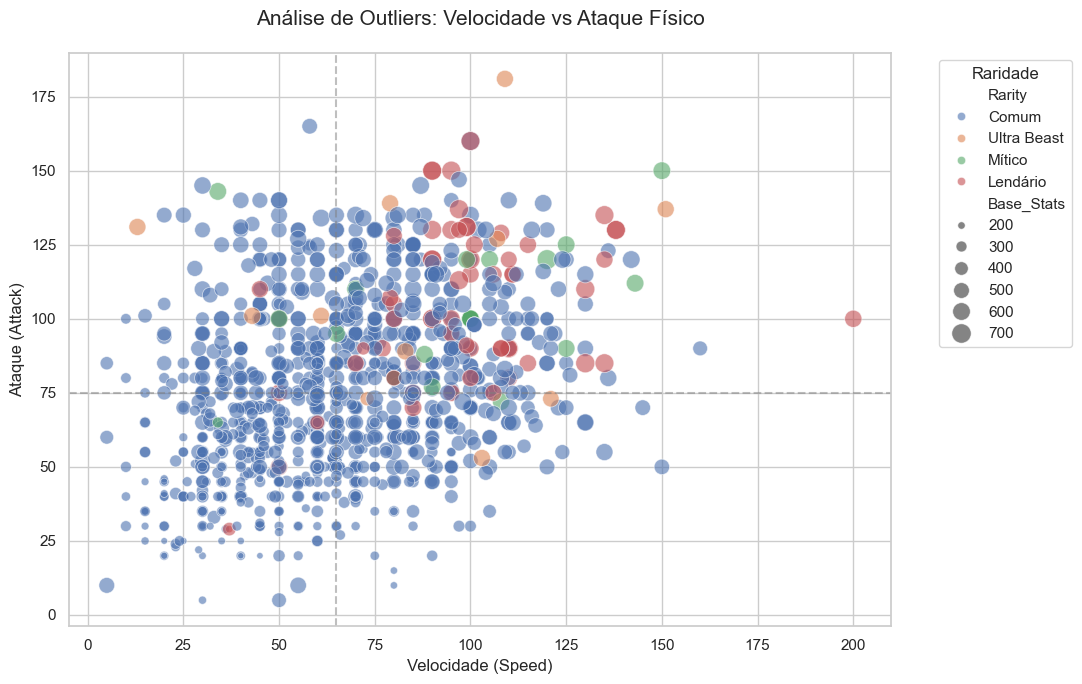

In [25]:
plt.figure(figsize=(11, 7))

# Criando o gráfico de dispersão com uma reta de regressão para ver a tendência
sns.scatterplot(data=df, x='Speed', y='Attack', hue='Rarity', size='Base_Stats', 
                sizes=(20, 200), alpha=0.6, palette="deep")

# Destacando quadrantes estratégicos
plt.axvline(x=df['Speed'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=df['Attack'].median(), color='gray', linestyle='--', alpha=0.5)

plt.title('Análise de Outliers: Velocidade vs Ataque Físico', fontsize=15, pad=20)
plt.xlabel('Velocidade (Speed)', fontsize=12)
plt.ylabel('Ataque (Attack)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Raridade')
plt.tight_layout()
plt.show()

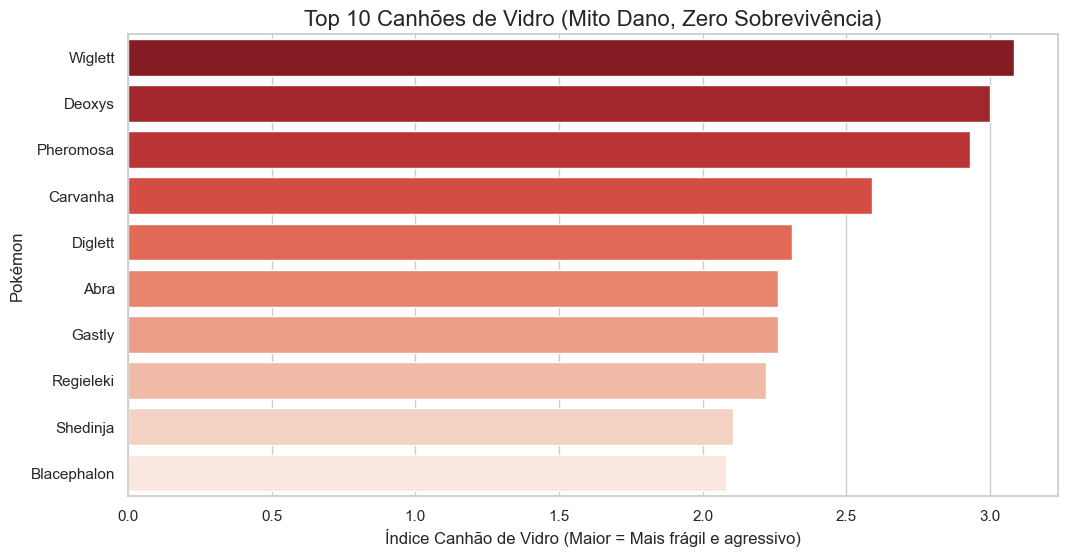

In [14]:
# Criando a métrica: (Ataque + Atq. Esp + Velocidade) / (HP + Defesa + Def. Esp)
df['Offensive_Stats'] = df['Attack'] + df['Sp. Attack'] + df['Speed']
df['Defensive_Stats'] = df['HP'] + df['Defense'] + df['Sp. Defense']

# Evitando divisão por zero (caso exista algum dado corrompido)
df['Defensive_Stats'] = df['Defensive_Stats'].replace(0, 1)

df['Glass_Cannon_Index'] = df['Offensive_Stats'] / df['Defensive_Stats']

# Pegando os 10 maiores índices
top_glass_cannons = df.nlargest(10, 'Glass_Cannon_Index')

plt.figure(figsize=(12, 6))
sns.barplot(x='Glass_Cannon_Index', y='Name', data=top_glass_cannons, hue='Name', palette='Reds_r', legend=False)
plt.title('Top 10 Canhões de Vidro (Mito Dano, Zero Sobrevivência)', fontsize=16)
plt.xlabel('Índice Canhão de Vidro (Maior = Mais frágil e agressivo)', fontsize=12)
plt.ylabel('Pokémon', fontsize=12)
plt.show()

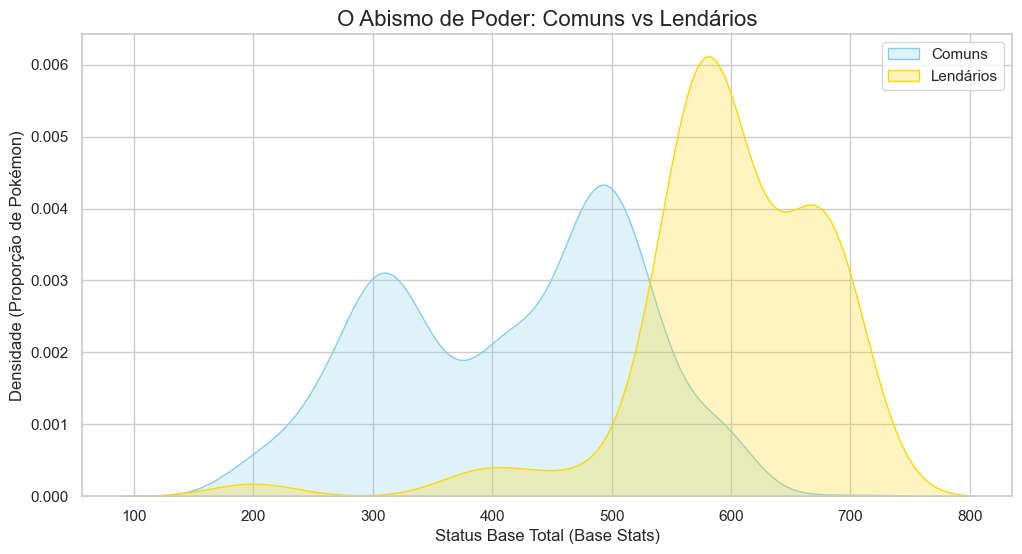

In [15]:
plt.figure(figsize=(12, 6))

# Plotando a curva dos Pokémon Comuns
sns.kdeplot(data=df[df['Is_Legendary'] == 0]['Base_Stats'], fill=True, color='skyblue', label='Comuns')

# Plotando a curva dos Pokémon Lendários
sns.kdeplot(data=df[df['Is_Legendary'] == 1]['Base_Stats'], fill=True, color='gold', label='Lendários')

plt.title('O Abismo de Poder: Comuns vs Lendários', fontsize=16)
plt.xlabel('Status Base Total (Base Stats)', fontsize=12)
plt.ylabel('Densidade (Proporção de Pokémon)', fontsize=12)
plt.legend()
plt.show()

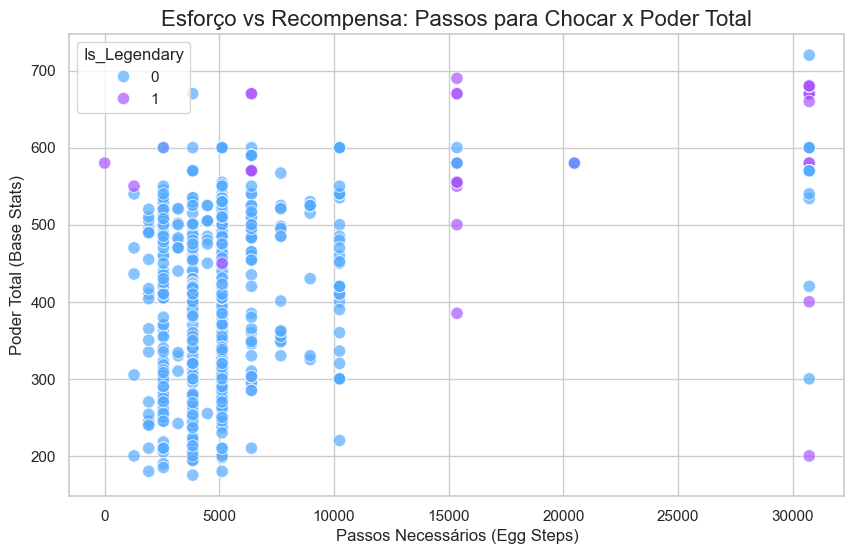

In [16]:
plt.figure(figsize=(10, 6))

# Garantindo que egg_steps seja numérico
df['egg_steps'] = pd.to_numeric(df['egg_steps'], errors='coerce')

# Plotando a relação
sns.scatterplot(x='egg_steps', y='Base_Stats', hue='Is_Legendary', 
                data=df, palette='cool', alpha=0.7, s=80)

plt.title('Esforço vs Recompensa: Passos para Chocar x Poder Total', fontsize=16)
plt.xlabel('Passos Necessários (Egg Steps)', fontsize=12)
plt.ylabel('Poder Total (Base Stats)', fontsize=12)
plt.show()

5. Matriz de Eficácia: O Coração da Estratégia

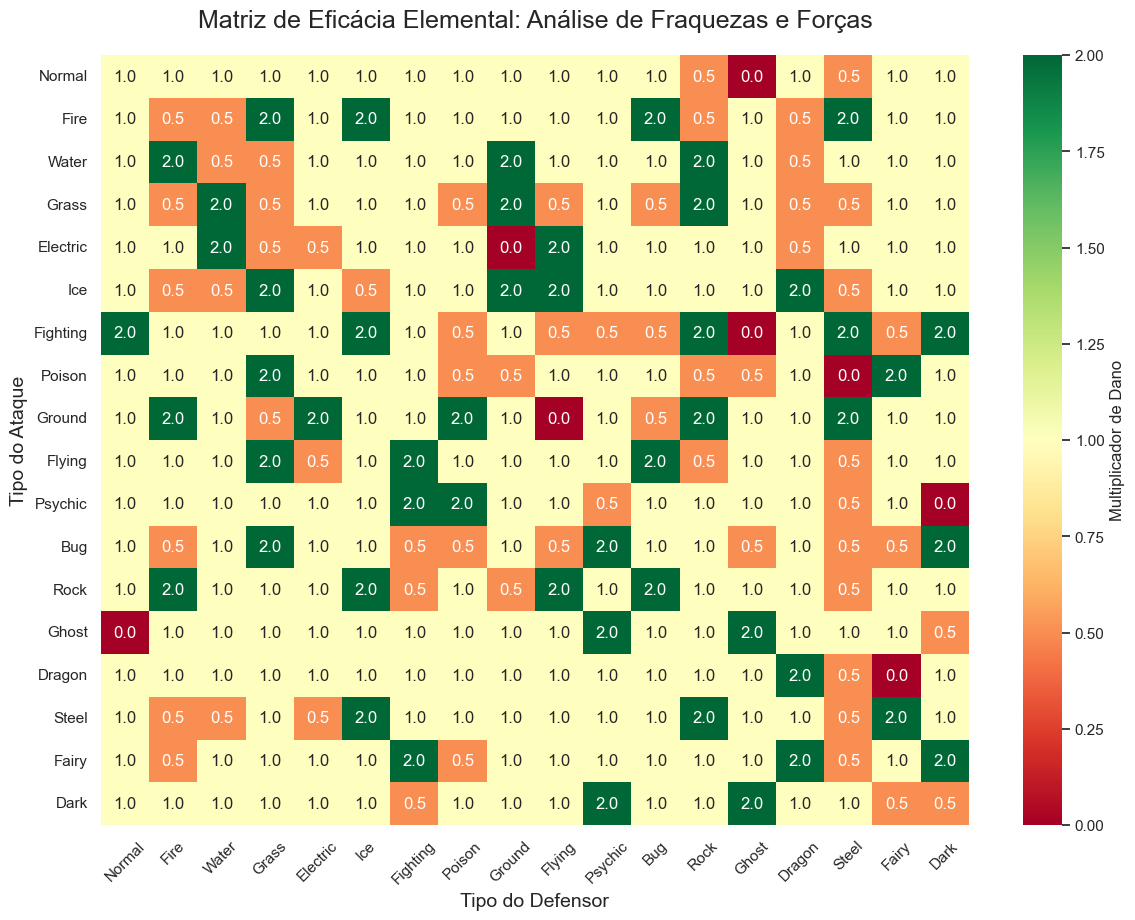

In [29]:
tipos = ['Normal', 'Fire', 'Water', 'Grass', 'Electric', 'Ice', 'Fighting', 'Poison', 'Ground', 
         'Flying', 'Psychic', 'Bug', 'Rock', 'Ghost', 'Dragon', 'Steel', 'Fairy', 'Dark']

# Matriz de eficácia (Linha: Atacante | Coluna: Defensor)
# 1.0: Neutro, 2.0: Super, 0.5: Resistente, 0.0: Imune
matriz_dados = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0.5, 0, 1, 0.5, 1, 1], # Normal
    [1, 0.5, 0.5, 2, 1, 2, 1, 1, 1, 1, 1, 2, 0.5, 1, 0.5, 2, 1, 1], # Fire
    [1, 2, 0.5, 0.5, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 0.5, 1, 1, 1], # Water
    [1, 0.5, 2, 0.5, 1, 1, 1, 0.5, 2, 0.5, 1, 0.5, 2, 1, 0.5, 0.5, 1, 1], # Grass
    [1, 1, 2, 0.5, 0.5, 1, 1, 1, 0, 2, 1, 1, 1, 1, 0.5, 1, 1, 1], # Electric
    [1, 0.5, 0.5, 2, 1, 0.5, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0.5, 1, 1], # Ice
    [2, 1, 1, 1, 1, 2, 1, 0.5, 1, 0.5, 0.5, 0.5, 2, 0, 1, 2, 0.5, 2], # Fighting
    [1, 1, 1, 2, 1, 1, 1, 0.5, 0.5, 1, 1, 1, 0.5, 0.5, 1, 0, 2, 1], # Poison
    [1, 2, 1, 0.5, 2, 1, 1, 2, 1, 0, 1, 0.5, 2, 1, 1, 2, 1, 1], # Ground
    [1, 1, 1, 2, 0.5, 1, 2, 1, 1, 1, 1, 2, 0.5, 1, 1, 0.5, 1, 1], # Flying
    [1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 0.5, 1, 1, 1, 1, 0.5, 1, 0], # Psychic
    [1, 0.5, 1, 2, 1, 1, 0.5, 0.5, 1, 0.5, 2, 1, 1, 0.5, 1, 0.5, 0.5, 2], # Bug
    [1, 2, 1, 1, 1, 2, 0.5, 1, 0.5, 2, 1, 2, 1, 1, 1, 0.5, 1, 1], # Rock
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 0.5], # Ghost
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0.5, 0, 1], # Dragon
    [1, 0.5, 0.5, 1, 0.5, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 0.5, 2, 1], # Steel
    [1, 0.5, 1, 1, 1, 1, 2, 0.5, 1, 1, 1, 1, 1, 1, 2, 0.5, 1, 2], # Fairy
    [1, 1, 1, 1, 1, 1, 0.5, 1, 1, 1, 2, 1, 1, 2, 1, 1, 0.5, 0.5]  # Dark
])

# 2. Configuração do Gráfico
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_dados, annot=True, fmt=".1f", cmap="RdYlGn", 
            xticklabels=tipos, yticklabels=tipos, cbar_kws={'label': 'Multiplicador de Dano'})

plt.title('Matriz de Eficácia Elemental: Análise de Fraquezas e Forças', fontsize=18, pad=20)
plt.xlabel('Tipo do Defensor', fontsize=14)
plt.ylabel('Tipo do Ataque', fontsize=14)
plt.xticks(rotation=45)
plt.show()

6. Conclusão da Exploração: A Ciência do Meta-Game
Esta análise exploratória revela que o sucesso no cenário competitivo de Pokémon (VGC) é um sistema multifatorial onde a superioridade estatística é apenas a base de uma pirâmide de decisões. A integração dos dados permitiu identificar três pilares críticos para a construção de times de alta performance:

I. Eficiência de Tipagem e Sinergia de Equipe
A análise unificada de tipos demonstra que a viabilidade de um Pokémon não é ditada apenas por suas fraquezas individuais, mas pela sua capacidade de compor um Core Defensivo.

Insight: A alta frequência de certos tipos (como Steel e Fairy) no meta exige que o jogador não apenas tenha cobertura ofensiva, mas entenda a densidade de resistências necessária para sobreviver a trocas (switches) sob pressão.

II. Dinâmica de Power Creep e Speed Tiers
O estudo das gerações confirmou a inflação de status ao longo do tempo.

Insight: A velocidade relativa é o recurso mais escasso e valioso. Compreender o deslocamento das Speed Tiers através das gerações permite aos jogadores prever se um Pokémon "clássico" ainda é capaz de exercer controle de mapa ou se será superado por novos atacantes naturalmente mais velozes.

III. Otimização de Recursos (EV Spreads & Damage Control)
Através da simulação de danos e análise de distribuição de EVs, fica evidente que o VGC é um jogo de margens.

Insight: A distribuição de EVs não deve ser aleatória; ela é uma ferramenta de engenharia para garantir que um Pokémon sobreviva a ataques específicos (survivability) ou garanta nocautes matemáticos (OHKOs). A gestão eficiente dos 510 pontos de esforço é o que separa um Pokémon "médio" de um set customizado para vencer confrontos específicos do meta atual.